<a href="https://colab.research.google.com/github/lucasrodriguesdias/NumPy-analise-numerica-eficiente-com-Python/blob/main/NumPy_an%C3%A1lise_num%C3%A9rica_eficiente_com_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##**EXERCÍCIO 1**

Esse dataset é uma versão modificada do arquivo Oranges vs. Grapefruit presente no site do Kaggle. Portanto, utilizaremos o arquivo raw disponível no GitHub.

Nessa etapa, você deve efetuar a leitura dos dados. Para isso, importe a NumPy e use a função loadtxt. Use o link da url e o parâmetro usecols para pular a primeira coluna. É possível usar np.arange para criar a sequência de números que representam as colunas. Por fim, também é necessário incluir o parâmetro skiprows=1 para que a primeira linha de texto seja desconsiderada na leitura do arquivo.

In [2]:
import numpy as np

url = 'https://raw.githubusercontent.com/allanspadini/numpy/dados/citrus.csv'

array = np.loadtxt(url, delimiter=',', usecols=np.arange(1, 6), skiprows=1)
array

array([[  2.96,  86.76, 172.  ,  85.  ,   2.  ],
       [  3.91,  88.05, 166.  ,  78.  ,   3.  ],
       [  4.42,  95.17, 156.  ,  81.  ,   2.  ],
       ...,
       [ 15.59, 256.5 , 168.  ,  82.  ,  20.  ],
       [ 15.92, 260.14, 142.  ,  72.  ,  11.  ],
       [ 16.45, 261.51, 152.  ,  74.  ,   2.  ]])

##**EXERCÍCIO 2**

Continuando com o projeto das laranjas/toranjas agora você deve selecionar parte dos dados. As colunas que iremos avaliar são as de diâmetro e peso. Crie arrays específicos para guardar o diâmetro e peso da laranja e toranja. O diâmetro está na coluna zero e o peso na coluna 1. Os dados referentes a laranja vão até a linha 4999 e os referentes à toranja iniciam na linha 5000 do arquivo.

Após fazer a seleção de dados, importe a biblioteca matplotlib e crie um gráfico para a laranja e para a toranja do peso pelo diâmetro.


1


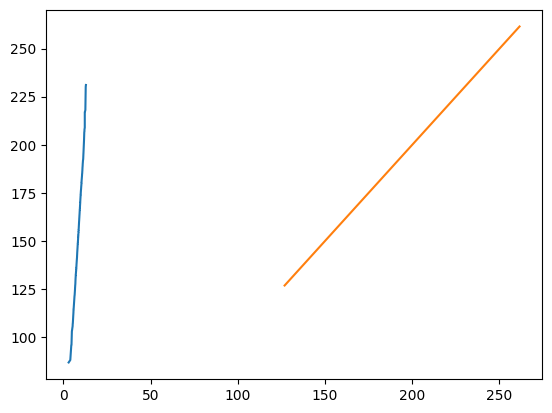

In [3]:
diamentro_laranja = array[:5000, 0]
peso_laranja = array[:5000, 1]
diamentro_toranja = array[5000:, 1]
peso_toranja = array[5000:, 1]

print(np.ndim(diamentro_laranja)) #só verificando as dimensões do array

import matplotlib.pyplot as plt

plt.plot(diamentro_laranja, peso_laranja)
plt.plot(diamentro_toranja, peso_toranja)

##**EXERCÍCIO 3**

Continuando com o projeto das laranjas/toranjas agora você deve calcular o coeficiente ângular e o linear para a reta da laranja e para a reta da toranja. Use a fórmula de mínimos quadrados para encontrar cada um.

**FÓRMULA PARA COEFICIENTE ANGULAR (a)**

â = coeficiente angular;

n = número de elementos;

Y = Peso.

X = Diametro.


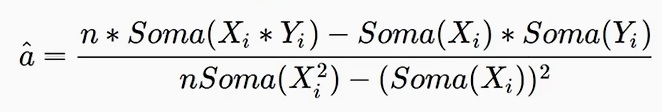

In [4]:
#Coeficiente angular

Y_laranja = peso_laranja
X_laranja = diamentro_laranja
Y_toranja = peso_toranja
X_toranja = diamentro_toranja

n = len(X_laranja)
a_laranja = (n*np.sum(X_laranja * Y_laranja) - np.sum(X_laranja) * np.sum(Y_laranja)) / (n*np.sum(X_laranja**2) - (np.sum(X_laranja))**2)

n = len(X_toranja)
a_toranja = (n*np.sum(X_toranja * Y_toranja) - np.sum(X_toranja) * np.sum(Y_toranja)) / (n*np.sum(X_toranja**2) - (np.sum(X_toranja))**2)


**FÓRMULA PARA COEFICIENTE LINEAR (b)**


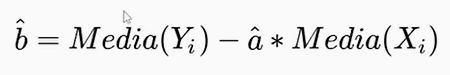

In [5]:
b_laranja = np.mean(Y_laranja) - a_laranja*np.mean(X_laranja)

b_toranja = np.mean(Y_toranja) - a_toranja*np.mean(X_toranja)

Resultado de a (Laranja): 14.7997452319846 - Resultado de b (Laranja): 27.38560381218413
Resultado de a (Toranja): 1.0 - Resultado de b (Toranja): 0.0


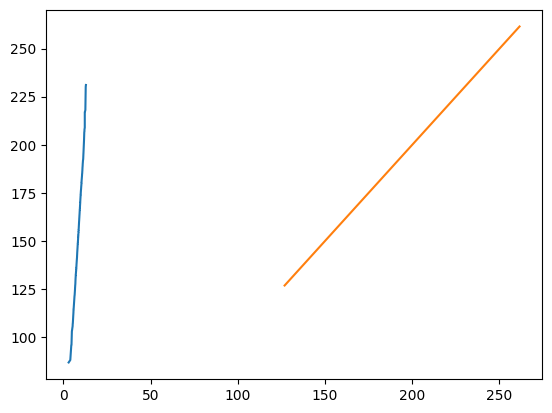

In [6]:
plt.plot(X_laranja, Y_laranja)
plt.plot(X_toranja, Y_toranja)
print(f'Resultado de a (Laranja): {a_laranja} - Resultado de b (Laranja): {b_laranja}')
print(f'Resultado de a (Toranja): {a_toranja} - Resultado de b (Toranja): {b_toranja}')

#**EXERCÍCIO 4**

Continuando com o projeto das laranjas/toranjas, agora você deve calcular o coeficiente angular utilizando a geração de números aleatórios. Assuma que já conhece b e que este é igual a 17.

In [15]:
np.random.seed(84)
coef_angular_laranja = np.random.uniform(low=0.10, high=30.0, size=100)
b_laranja = 17
norma_laranja = np.array([])
for i in range(100):
  norma_laranja = np.append(norma_laranja,np.linalg.norm(Y_laranja - (coef_angular_laranja[i]* X_laranja + b_laranja)))


np.random.seed(84)
coef_angular_toranja = np.random.uniform(low=0.10, high=30.0, size=100)
b_toranja = 17
norma_toranja = np.array([])
for i in range(100):
  norma_toranja = np.append(norma_toranja,np.linalg.norm(Y_toranja - (coef_angular_toranja[i]* X_toranja + b_toranja)))



In [18]:
print(f'C Angular laranja = {coef_angular_laranja}\n')
print(f'C Angular toranja = {coef_angular_toranja}\n')

indice_laranja = np.argmin(norma_laranja)
melhor_coef_laranja = coef_angular_laranja[indice_laranja]

print("Melhor coef angular laranja:", melhor_coef_laranja)

indice_toranja = np.argmin(norma_toranja)
melhor_coef_toranja = coef_angular_toranja[indice_toranja]

print("Melhor coef angular toranja:", melhor_coef_toranja)

C Angular laranja = [ 1.47662571 11.17024525  7.3453162  18.89155215 29.70429079  4.00458267
  5.29031598  7.82359032 12.6101291   4.01746491  8.78445875 14.90965223
 29.013429    8.99195691 19.5888779  16.11482564 26.62208879 25.9514876
 28.22193141  3.26441084 18.43534736  5.43986525  2.31789407 29.87838892
 10.75259192 25.20028721 19.17833533  6.36775371 29.35496553  4.23849977
 16.64137098  8.07535791  9.41958505  9.99685049  4.46034503 24.64069923
  4.91741154 15.00046675  9.99784048  5.92578371  4.47519422 20.63310717
 29.83911115  8.61423665 17.02913886  3.69719568  1.39655209  4.81977359
 13.04712731 11.37874141  1.89927348 18.78264031 14.68511985 12.41031206
 13.60089212 16.62302246 28.05109903  8.00597918  0.62861173 20.98253869
 24.23954914 19.30605035 15.87237159 24.98767006 10.59816905  5.76795262
  0.61680711 29.42367623 24.34961585 28.8277785   0.48065839  8.5651387
  6.89685963  0.18169288 10.53393968 13.25046498  5.52775855 15.28401415
  8.55578894 28.56621692 14.29808